In [2]:
from pathlib import Path
from typing import Any, Dict, List

import numpy as np
import pandas as pd

from scripts.model_registry import ModelRegistry
from scripts.shap import excecute_shap, extract_shap_importance

In [3]:
%load_ext autoreload
%autoreload 2

# Data loading

In [4]:
data_path = Path("data")

train_df = pd.read_csv(data_path / "titanic" / "train.csv")
test_df = pd.read_csv(data_path / "titanic" / "test.csv")

combined_df = pd.concat([train_df, test_df])

target = "Survived"

# Feature engineering

## Functions

In [5]:
def corrwt(col_names: List[str]) -> pd.DataFrame:
    return combined_df.groupby(col_names, observed=False)[target].agg(["mean", "count"])


def build_family_size_feature(df: pd.DataFrame) -> pd.Series:
    family_size = df["SibSp"] + df["Parch"] + 1
    return family_size


def build_family_size_cat_feature(df: pd.DataFrame) -> pd.Series:
    family_size = df["SibSp"] + df["Parch"] + 1
    bins = [-np.inf, 1, 2, 4, np.inf]
    labels = ["alone", "small", "medium", "large"]
    return pd.Series(pd.cut(family_size, bins=bins, labels=labels).astype("category"))


def build_ticket_group_size_cat_feature(df: pd.DataFrame) -> pd.Series:
    bins = [-np.inf, 1, 2, 4, np.inf]
    labels = ["alone", "small", "medium", "large"]
    return pd.Series(pd.cut(df["Ticket_group_size"], bins=bins, labels=labels).astype("category"))


def build_age_cat_feature(df: pd.DataFrame) -> pd.Series:
    bins = 5
    labels = ["child", "young", "adult", "middle-aged", "elderly"]
    return pd.Series(pd.cut(df["Age"], bins=bins, labels=labels))


def build_fare_per_person_cat_feature(df: pd.DataFrame) -> pd.Series:
    q = 4
    labels = ["poor", "middle", "upper-middle", "rich"]
    return pd.Series(pd.qcut(df["Fare_per_person"], q=q, labels=labels))


def build_name_len_cat_feature(df: pd.DataFrame) -> pd.Series:
    q = 4
    labels = ["short", "medium", "long", "extra-long"]
    return pd.Series(pd.qcut(df["Name_len"], q=q, labels=labels).astype("category"))


def build_title_feature(df: pd.DataFrame) -> pd.Series:
    res = df["Name"].str.split(",", expand=True)[1].str.split(" ", expand=True)[1]
    return res


def build_title_cat_feature(df: pd.DataFrame) -> pd.Series:
    labels = ["Mr.", "Miss.", "Mrs.", "Master."]
    res = pd.Series(
            np.where(df["Title"].isin(labels), df["Title"], "else")
            ).astype("category")
    return res


def build_fare_imputed_feature(df: pd.DataFrame) -> pd.Series:
    fare = df["Fare"].copy()
    pclass_median = df.groupby("Pclass")["Fare"].transform("median")
    fare = fare.fillna(pclass_median)
    return fare


def build_age_imputed_feature(df: pd.DataFrame) -> pd.Series:
    age = df["Age"].copy()

    child_median = df.loc[df["Age"] < 18, "Age"].median()
    adult_median = df.loc[df["Age"] >= 18, "Age"].median()
    global_median = df["Age"].median()

    child_median = child_median if pd.notna(child_median) else 5.0
    adult_median = adult_median if pd.notna(adult_median) else 28.0
    global_median = global_median if pd.notna(global_median) else 28.0

    conditions = [
        (df["Title"].isin(["Mrs", "Miss"])) & age.isna(),
        (df["Title"] == "Master") & age.isna(),
        (df["Title"] == "Mr") & age.isna(),
        ]
    choices = [18.0, child_median, adult_median]

    age = pd.Series(np.select(conditions, choices, default=age), index=df.index)
    age = age.fillna(global_median)

    return age

## Data preprocessing and dataset creation

In [6]:
data_path = Path("data")

train_df = pd.read_csv(data_path / "titanic" / "train.csv")
test_df = pd.read_csv(data_path / "titanic" / "test.csv")

combined_df = pd.concat([train_df, test_df], ignore_index=True)

# processing:
combined_df["Sex"] = combined_df["Sex"].astype("category")

combined_df["Family_size"] = build_family_size_feature(combined_df)
combined_df["Family_size_cat"] = build_family_size_cat_feature(combined_df)

combined_df["Ticket_group_size"] = combined_df.groupby("Ticket")["Ticket"].transform("count")
combined_df["Ticket_group_size_cat"] = build_ticket_group_size_cat_feature(combined_df)

combined_df["Fare"] = build_fare_imputed_feature(combined_df)
combined_df["Fare_per_person"] = combined_df["Fare"] / combined_df["Ticket_group_size"]
combined_df["Fare_per_person_cat"] = build_fare_per_person_cat_feature(combined_df)

# based on data I made my own prediction that the 2 missing values are S
combined_df["Embarked"] = combined_df["Embarked"].fillna("S").astype("category")

combined_df["Name_len"] = combined_df["Name"].str.len()
combined_df["Name_len_cat"] = build_name_len_cat_feature(combined_df)

combined_df["Title"] = build_title_feature(combined_df)
combined_df["Title_cat"] = build_title_cat_feature(combined_df)

combined_df["Cabin_cat"] = combined_df["Cabin"].str[0].fillna("U").astype("category")

combined_df["Age"] = build_age_imputed_feature(combined_df)
combined_df["Age_cat"] = build_age_cat_feature(combined_df)

info_df = pd.DataFrame(
        {
            "dtype"         : combined_df.dtypes,
            "non_null_count": combined_df.count(),
            "null_count"    : combined_df.isna().sum(),
            "null_pct"      : (combined_df.isna().mean() * 100).round(2),
            "n_unique"      : combined_df.nunique(),
            }
        )

train_df = combined_df.loc[combined_df[target].notna()]
test_df = combined_df.loc[combined_df[target].isna()]

info_df.reset_index()

,index,dtype,non_null_count,null_count,null_pct,n_unique
0,PassengerId,int64,1309,0,0.00,1309
1,Survived,float64,891,418,31.93,2
2,Pclass,int64,1309,0,0.00,3
3,Name,str,1309,0,0.00,1307
4,Sex,category,1309,0,0.00,2
5,Age,float64,1309,0,0.00,98
6,SibSp,int64,1309,0,0.00,7
7,Parch,int64,1309,0,0.00,8
8,Ticket,str,1309,0,0.00,929
9,Fare,float64,1309,0,0.00,281


# Overview of approaches

**List 1: Single Base Models (Categorized by Algorithmic Family)**

*Linear and Distance-Based Models* (Require strict feature scaling and numerical encoding; sensitive to multicollinearity)
1. Logistic Regression (`LogisticRegression`)
2. Support Vector Classifier (`SVC`)
3. K-Nearest Neighbors (`KNeighborsClassifier`)
4. Linear Discriminant Analysis (`LinearDiscriminantAnalysis`)
5. Gaussian Naive Bayes (`GaussianNB`)

*Tree-Based Ensembles* (Invariant to monotonic scaling; natively handle non-linear relationships and feature interactions)
1. Random Forest (`RandomForestClassifier`)
2. Extra Trees (`ExtraTreesClassifier`)
3. Gradient Boosting (`GradientBoostingClassifier`)
4. AdaBoost (`AdaBoostClassifier`)
5. XGBoost (`XGBClassifier`)
6. LightGBM (`LGBMClassifier`)
7. CatBoost (`CatBoostClassifier`)
8. HistGradientBoosting (`HistGradientBoostingClassifier`)

*Interpretability and Advanced Baselines*
1. Decision Tree (`DecisionTreeClassifier`) – For baseline interpretability and maximum depth analysis.
2. TabNet (`TabNetClassifier`) – For pedagogical exploration of attention-based feature selection in tabular deep learning.
3. Modern Tuned MLP: Establishes the strict baseline for feed-forward networks.
4. TabPFN: Demonstrates in-context learning and meta-learning capabilities on small datasets.
5. FT-Transformer: Explores self-attention mechanisms for modeling high-order feature interactions.

**List 2: Ensemble Methodologies**

1. Soft Voting (`VotingClassifier(voting='soft')`) – Baseline ensemble averaging predicted probabilities. Requires all base models to output calibrated probabilities.
2. Optimized Weighted Averaging – Uses constrained optimization (e.g., `scipy.optimize.minimize`) to learn the exact probability weights for each base model that minimize log loss on a hold-out validation fold, superseding uniform soft voting.
3. Out-of-Fold (OOF) Blending – Generates leakage-free predictions by training base models on K-1 folds and predicting the held-out Kth fold. These OOF predictions form the dataset for the next stage, ensuring strict separation between training and meta-evaluation.
4. Stacked Generalization (Stacking) (`StackingClassifier`) – The Kaggle standard. Trains diverse Level-0 base models, generates OOF predictions, and trains a Level-1 meta-learner (e.g., `Ridge` or `LogisticRegression`) to optimally combine the base models' outputs based on their learned error patterns.
5. Ensemble Selection (Greedy Forward Selection) – Iteratively adds the model (or specific hyperparameter configuration) from a candidate pool that yields the maximum marginal improvement to the cross-validated ensemble score, automatically pruning redundant or noisy models.

In [7]:
model_registry = ModelRegistry()

# Single Base models
## Linear and Distance-Based Models

### Logistic Regression

**Historical Context**
The underlying logistic function was formulated by Pierre François Verhulst between 1838 and 1847 to model population growth. The statistical framework for binary regression was formally established by David R. Cox in 1958 in his seminal paper, *The Regression Analysis of Binary Sequences*.

**Mathematical Formulation**
Logistic regression models the log-odds of the probability of a binary event as a linear combination of independent variables.

Let $\mathbf{x} \in \mathbb{R}^d$ be the feature vector, $\mathbf{w} \in \mathbb{R}^d$ the weight vector, and $b \in \mathbb{R}$ the bias term. The linear predictor is defined as:
$$ z = \mathbf{w}^T\mathbf{x} + b $$

The logistic sigmoid function maps the unbounded linear predictor $z$ to the probability space $[0, 1]$:
$$ P(Y=1|\mathbf{x}) = \sigma(z) = \frac{1}{1 + \exp(-z)} $$

The model parameters are estimated by minimizing the empirical risk, specifically the Binary Cross-Entropy (Log-Loss) function over $N$ training samples:
$$ \mathcal{L}(\mathbf{w}, b) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\sigma(z_i)) + (1 - y_i) \log(1 - \sigma(z_i)) \right] + \lambda \Omega(\mathbf{w}) $$

where $y_i \in \{0, 1\}$ is the true label, and $\lambda \Omega(\mathbf{w})$ represents the regularization penalty (L1/Lasso, L2/Ridge, or Elastic Net). Regularization is mathematically critical in this formulation to constrain model complexity, enforce sparsity (in L1), and mitigate the variance inflation caused by multicollinearity among engineered features.

In [8]:
combined_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family_size',
       'Family_size_cat', 'Ticket_group_size', 'Ticket_group_size_cat',
       'Fare_per_person', 'Fare_per_person_cat', 'Name_len', 'Name_len_cat',
       'Title', 'Title_cat', 'Cabin_cat', 'Age_cat'],
      dtype='str')

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, BaseCrossValidator, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler


def define_feature_subsets(
        numeric_features: List[str],
        nominal_categorical_features: List[str],
        ordinal_categorical_features: List[str]
        ) -> dict:
    features = dict()
    features["numeric_features"] = numeric_features
    features["nominal_categorical_features"] = nominal_categorical_features
    features["ordinal_features"] = ordinal_categorical_features
    return features


def build_preprocessor(features: Dict[str, List[str]]) -> ColumnTransformer:
    numeric_transformer = Pipeline(
            steps=[
                ("scaler", StandardScaler())]
            )
    nominal_transformer = Pipeline(
            steps=[
                ("onehot", OneHotEncoder(handle_unknown="ignore"))]
            )
    ordinal_transformer = Pipeline(
            steps=[
                ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]
            )

    preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, features["numeric_features"]),
                ("nom", nominal_transformer, features["nominal_categorical_features"]),
                ("ord", ordinal_transformer, features["ordinal_features"]), ]
            )
    return preprocessor


def prepare_features_and_target(
        dataframe: pd.DataFrame,
        target_column: str,
        features: Dict[str, List[str]]
        ) -> tuple([pd.DataFrame, pd.Series]):
    columns = []
    for key in features.keys():
        columns.extend(features[key])
    features_matrix: pd.DataFrame = dataframe[columns]
    target: pd.Series = dataframe[target_column]
    return features_matrix, target


def build_logistic_regression_pipeline(preprocessor: ColumnTransformer) -> Pipeline:
    classifier = LogisticRegression(
            C=1.0,
            l1_ratio=0.0,
            solver="saga",
            max_iter=5000,
            tol=1e-4,
            random_state=42
            )
    pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", classifier)
                ]
            )
    return pipeline


def train_and_evaluate_model(
        pipeline: Pipeline, feature_matrix: pd.DataFrame, target_vector: pd.Series, n_splits: int = 5,
        random_state: int = 42
        ) -> float:
    cross_validation = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = cross_val_score(
            estimator=pipeline,
            X=feature_matrix,
            y=target_vector,
            cv=cross_validation,
            scoring="accuracy"
            )
    return float(scores.mean())


def define_logistic_regression_search_space(
        classifier_c: list[float] | None = None,
        classifier_l1_ratio: list[float] | None = None
        ) -> dict[str, list[Any]]:
    if classifier_c is None:
        classifier_c = [0.01, 0.1, 1.0, 10.0, 100.0]
    if classifier_l1_ratio is None:
        classifier_l1_ratio = [0.0, 0.25, 0.5, 0.75, 1.0]

    search_space: dict[str, list[Any]] = {
        "classifier__C"       : classifier_c,
        "classifier__l1_ratio": classifier_l1_ratio,
    }
    return search_space


def tune_logistic_regression_hyperparameters(
        pipeline: Pipeline,
        feature_matrix: pd.DataFrame,
        target_vector: pd.Series,
        search_space: Dict[str, List[Any]],
        cross_validator: BaseCrossValidator,
        scoring: str = "accuracy"
        ) -> Dict[str, Any]:
    grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=search_space,
            scoring=scoring,
            cv=cross_validator,
            n_jobs=1,
            refit=True,
            error_score="raise"
            )

    grid_search.fit(feature_matrix, target_vector)

    return {
        "best_pipeline"  : grid_search.best_estimator_,
        "best_parameters": grid_search.best_params_,
        "best_score"     : float(grid_search.best_score_)
    }

### Base

In [10]:
features = define_feature_subsets(
        numeric_features=["Age", "SibSp", "Parch", "Fare", "Family_size",
                          "Ticket_group_size", "Fare_per_person", "Name_len"],
        nominal_categorical_features=["Sex", "Embarked"],
        ordinal_categorical_features=["Pclass", "Title_cat", "Cabin_cat"]
        )

f, t = prepare_features_and_target(train_df, "Survived", features)
lr_preprocessor = build_preprocessor(features)
pipeline_lr = build_logistic_regression_pipeline(lr_preprocessor)
base_score = train_and_evaluate_model(pipeline_lr, f, t)
print(f"Base score: {base_score:.4f}")

Base score: 0.8002


### Tuned

In [11]:
lr_b_model = tune_logistic_regression_hyperparameters(
    pipeline_lr, f, t, define_logistic_regression_search_space(), StratifiedKFold()
    )

### SHAP

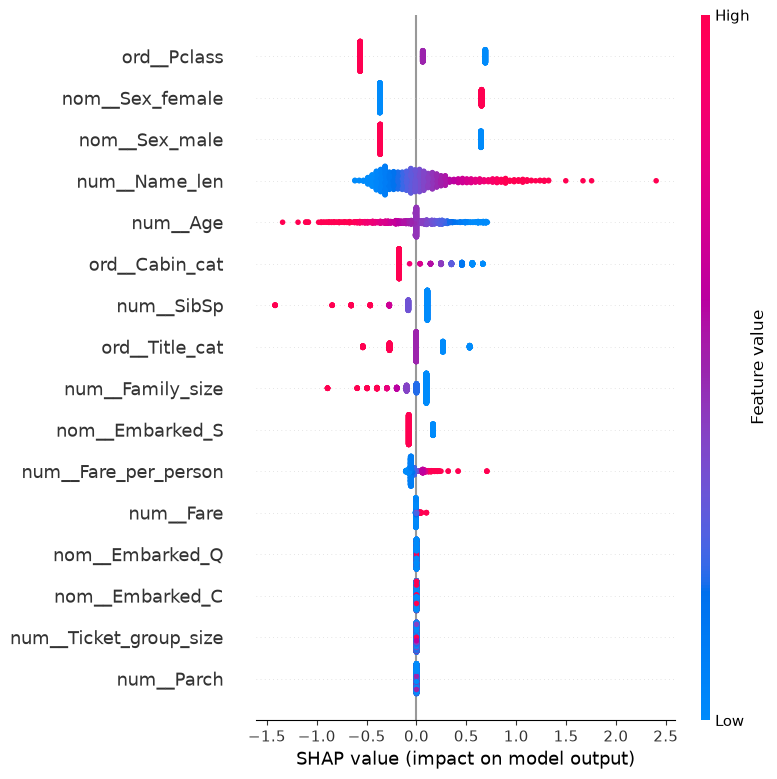

In [12]:
lr_shap_vals = excecute_shap(model_data=lr_b_model, features=f, target=t)

In [13]:
extract_shap_importance(lr_shap_vals)

,feature,mean_abs_shap
0,ord__Pclass,0.491405
1,nom__Sex_female,0.467813
2,nom__Sex_male,0.463274
3,num__Name_len,0.293927
4,num__Age,0.232918
5,ord__Cabin_cat,0.229319
6,num__SibSp,0.139481
7,ord__Title_cat,0.133922
8,num__Family_size,0.110000
9,nom__Embarked_S,0.102115


### Register model

In [27]:
model_registry.register(
        model_name="LogisticRegression_SAGA",
        best_parameters=lr_b_model["best_parameters"],
        pipeline=lr_b_model["best_pipeline"],
        metrics={
            "accuracy"  : lr_b_model["best_score"],
            "base_score": base_score
            }
        )
model_registry.show()

### Semi-conclusion
* **Core Mechanism**: The Linear Boundary
Logistic Regression solves binary classification by constructing a linear hyperplane. The model computes the linear projection of the feature vector onto the weight vector. The hard classification rule is strictly deterministic: a positive projection assigns class 1, and a negative projection assigns class 0. In this geometric sense, it operates identically to a linear perceptron.
* **The Probabilistic Shift**: Sigmoid and Log-Loss
Unlike margin-based classifiers, Logistic Regression does not output a raw geometric distance. Instead, it passes the linear projection through a sigmoid function, mapping the unbounded output into a strict probability between 0 and 1. The model is trained not by maximizing a safety margin, but by minimizing Binary Cross-Entropy (Log-Loss). This objective function optimizes the global probability distribution, heavily penalizing the model for highly confident misclassifications.
* **The Risk of No Margin and Regularization**
Because Logistic Regression lacks a geometric margin, it does not inherently ignore points far from the boundary; every data point influences the hyperplane's position. This makes the standard model highly sensitive to extreme outliers. To mitigate this risk, the algorithm employs L1 or L2 regularization (controlled by the inverse strength parameter $C$). Regularization constrains the magnitude of the weights, preventing any single feature or outlier from exerting disproportionate leverage. This weight constraint acts as a probabilistic substitute for a geometric margin, ensuring a stable and generalizable decision boundary.

## Support Vector Machine